# Import all necessary libraries

In [1]:
import pandas as pd                  
import numpy as np                    
import matplotlib.pyplot as plt        
import seaborn as sns                  


from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn.preprocessing import LabelEncoder    
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score   
from xgboost import XGBRegressor
import pickle
   



In [2]:
df=pd.read_csv("preprocessed_data.csv")

In [3]:
df.head()

,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted_price,Sell through Rate
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


# Feature selection

In [4]:
df.columns

Index(['Unnamed: 0', 'Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday',
       'Discounted_price', 'Sell through Rate'],
      dtype='str')

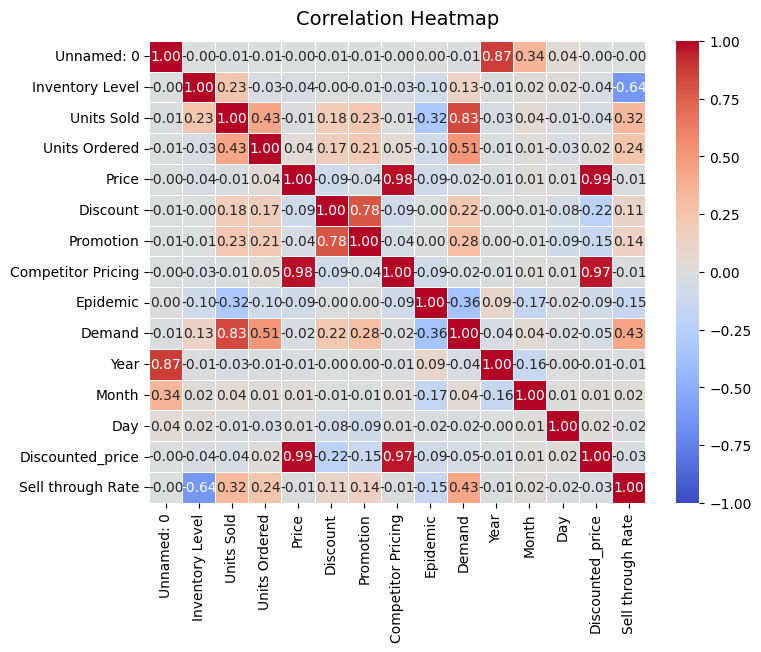

In [5]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# Set up figure size
plt.figure(figsize=(8, 6))

# Generate the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation coefficients inside cells
    cmap="coolwarm",  # Diverging colormap
    vmin=-1,  # Set color bar minimum value
    vmax=1,  # Set color bar maximum value
    fmt=".2f",  # Round coefficients to 2 decimal places
    linewidths=0.5,  # Add fine grid lines between cells
)

# Add title and render
plt.title("Correlation Heatmap", fontsize=14, pad=12)
plt.show()


In [10]:
feature=["Price", 'Inventory Level', 'Discount', 'Promotion', 'Competitor Pricing', "Category"]
feature

['Price',
 'Inventory Level',
 'Discount',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [7]:
target= ["Demand"]

# Model Training

In [11]:
X= df[feature].copy()

In [12]:
y=df[target]

### Label Encoding

In [14]:
label_encoder={}
categorical_cols= X.select_dtypes(include="object").columns

C:\Users\Nayeem\AppData\Local\Temp\ipykernel_10748\923973852.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols= X.select_dtypes(include="object").columns


In [15]:
categorical_cols

Index(['Category'], dtype='str')

In [16]:
for col in categorical_cols:
    le= LabelEncoder()
    X[col]= le.fit_transform(X[col])
    label_encoder[col]=le

In [17]:
label_encoder

{'Category': LabelEncoder()}

In [18]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2)